<a href="https://colab.research.google.com/github/kakopappa/Fine-tuning-LFM2.5-350M-on-Sharp-CV-P09FX-AC-Manual/blob/main/AC_Manual_Finetune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sharp CV-P09FX AC Manual Assistant

This notebook demonstrates fine-tuning the **LiquidAI/LFM2.5-350M** model using **Unsloth** and **QLoRA** to act as a specialized technical assistant for the Sharp CV-P09FX Portable Air Conditioner.

## 🚀 Project Overview
The goal is to transform a general-purpose lightweight language model into a domain-specific expert that provides accurate technical specifications (power requirements, fan modes, maintenance, etc.) based strictly on the product manual.

## 🛠️ Technical Configuration
To overcome the challenges of a small model (350M parameters) overriding its pre-trained knowledge, we utilized the following specialized settings:

*   **Framework**: [Unsloth](https://github.com/unslothai/unsloth) (2x faster fine-tuning).
*   **Quantization**: 4-bit QLoRA for efficient memory usage.
*   **LoRA Rank (r)**: 64 (Increased capacity for fact retention).
*   **LoRA Alpha**: 32.
*   **Epochs**: 30 (Extended training to ensure memorization of manual details).
*   **Learning Rate**: 2e-4.
*   **Prompt Format**: ChatML.

## 📂 Dataset Structure
The model is trained on a `.jsonl` file located at `./sample_data/ac_manual_chatml.jsonl`. Each entry follows the ChatML format:
```json
{
  "text": "<|im_start|>system\n...<|im_end|>\n<|im_start|>user\n...<|im_end|>\n<|im_start|>assistant\n...<|im_end|>"
}
```

## 📖 How to Use
1.  **Install Dependencies**: Run the first cell to install `unsloth`, `trl`, and `bitsandbytes`.
2.  **Fine-Tuning**: Run the training cell. It will load the base model, apply LoRA adapters, and save the result to `./lfm25_350m_ac_lora`.
3.  **Inference**: Run the inference cell to load the fine-tuned adapters. You can use the `ask()` function or the interactive loop to query the assistant.

## ⚠️ Important Note
If the model produces incorrect technical specs (e.g., wrong voltage), ensure the `SYSTEM_PROMPT` during inference matches the training prompt exactly: *\"Answer questions accurately based on the product manual.\"*

In [1]:
# Install necessary libraries
!pip install "unsloth[cu121-torch260]" trl datasets huggingface_hub hf_transfer bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.2/421.2 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/

In [3]:
# ============================================================
# Fine-tune LFM2.5-350M on Sharp CV-P09FX AC Manual Dataset
# Uses Unsloth + QLoRA + SFTTrainer
# ============================================================

import os
import torch
from datasets import load_dataset
from unsloth import FastLanguageModel, is_bfloat16_supported
from trl import SFTTrainer, SFTConfig

# ──────────────────────────────────────────────
# 1. CONFIG
# ──────────────────────────────────────────────
MODEL_NAME      = "LiquidAI/LFM2.5-350M"
DATASET_PATH    = "./ac_manual_chatml_tra.jsonl"
VAL_DATASET_PATH   = "./ac_manual_chatml_val.jsonl"

OUTPUT_DIR      = "./outputs"
LORA_SAVE_DIR   = "./lfm25_350m_ac_lora"

MAX_SEQ_LENGTH  = 512 # This is the 'sentence limit.' It tells the model the maximum number of words (tokens) it can read or write at once. 512 is plenty for most manual Q&As.
LOAD_IN_4BIT    = True # This is 'memory compression.' It shrinks the model so it fits on a standard GPU (like the T4 in Colab) without losing much intelligence.
LORA_RANK       = 64 #  This is the 'learning capacity.' a higher number like 64 gives the model more 'storage space' to memorize specific technical facts from your manual.
LORA_ALPHA      = 32 # This is the 'volume knob' for the new knowledge. It controls how much the new AC manual data should influence the final answer compared to the original model knowledge.
LORA_DROPOUT    = 0.0 # This is a 'focus setting.' Setting it to 0.0 means the model uses all its new neurons. (Higher values are usually used to prevent overfitting in very large datasets).
RANDOM_STATE    = 3407 # This is the 'repeatability key.' Using a specific number ensures that if you run the training again, you'll get the exact same results every time.

# Training hyperparams
NUM_EPOCHS                  = 30 # This is how many times the model reads the entire manual. We set it high (30) so the model 'memorizes' the technical facts correctly.
PER_DEVICE_TRAIN_BATCH_SIZE = 2 # This is how many questions the model looks at simultaneously. A small number (2) is used to save memory on the GPU.
GRADIENT_ACCUMULATION_STEPS = 4 # This works with the batch size. It waits until it has processed 4 batches (Total of 8 questions) before updating its brain. This simulates a larger, more stable training session.
LEARNING_RATE               = 2e-4 # This is the 'step size.' A small number means the model learns carefully. Too high, and it might 'trip' and fail to learn; too low, and it will take forever.
WEIGHT_DECAY                = 0.01 # This is like a 'simplicity tax.' It penalizes the model for making its internal math too complicated, which helps prevent overfitting.
WARMUP_STEPS                = 10 # This is the 'warm-up lap.' The model starts with a very tiny learning rate and slowly increases it for the first 10 steps to avoid a sudden shock to its weights.
LR_SCHEDULER                = "cosine"
OPTIM                       = "adamw_8bit"
LOGGING_STEPS               = 1 # This tells the model to show you its progress (loss) after every single step.
SAVE_STEPS                  = 50 # This creates a 'backup' of the model's progress every 50 steps.
MAX_STEPS                   = -1 # This tells the trainer to ignore step limits and just finish all the Epochs we asked for.

# 2. LOAD MODEL
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    load_in_4bit = LOAD_IN_4BIT,
    trust_remote_code = True,
)

# 3. APPLY LoRA. (attach the 'extra memory' (LoRA adapters) to the model)
model = FastLanguageModel.get_peft_model(
    model,
    r = LORA_RANK,
    target_modules = ["q_proj", "k_proj", "v_proj", "out_proj", "in_proj", "w1", "w2", "w3"],
    lora_alpha = LORA_ALPHA,
    lora_dropout = LORA_DROPOUT,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = RANDOM_STATE,
)

# 4. LOAD DATASET
dataset = load_dataset("json", data_files = DATASET_PATH, split = "train")
val_dataset = load_dataset("json", data_files = VAL_DATASET_PATH, split = "train")

# 5. TRAINER
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    eval_dataset = val_dataset,
    dataset_text_field = "text",
    max_seq_length = MAX_SEQ_LENGTH,
    args = SFTConfig(
        output_dir = OUTPUT_DIR,
        num_train_epochs = NUM_EPOCHS,
        per_device_train_batch_size = PER_DEVICE_TRAIN_BATCH_SIZE,
        gradient_accumulation_steps = GRADIENT_ACCUMULATION_STEPS,
        warmup_steps = WARMUP_STEPS,
        learning_rate = LEARNING_RATE,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = LOGGING_STEPS,
        optim = OPTIM,
        weight_decay = WEIGHT_DECAY,
        lr_scheduler_type = LR_SCHEDULER,
        seed = RANDOM_STATE,
        report_to = "none",
        eval_strategy = "steps",      # Fixed: Added evaluation strategy
        eval_steps = 5,
        save_strategy = "steps",      # Added: Matches evaluation strategy
        save_steps = 50,
        per_device_eval_batch_size = 4,
        load_best_model_at_end = True,
        metric_for_best_model = "eval_loss",
    ),
)

print("\nStarting training with 30 epochs...")
trainer.train()

model.save_pretrained(LORA_SAVE_DIR)
tokenizer.save_pretrained(LORA_SAVE_DIR)
print("Done training.")

Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.4.6: Fast Lfm2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/45 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/46 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.

Starting training with 30 epochs...


Step,Training Loss,Validation Loss
5,5.893681,6.498118
10,3.828689,3.493443
15,2.336797,2.162060
20,1.817129,1.700820
25,1.366155,1.450966
30,1.255095,1.316900
35,0.648322,1.257297
40,0.565655,1.289240
45,0.284346,1.379395
50,0.188878,1.515049


Done training.


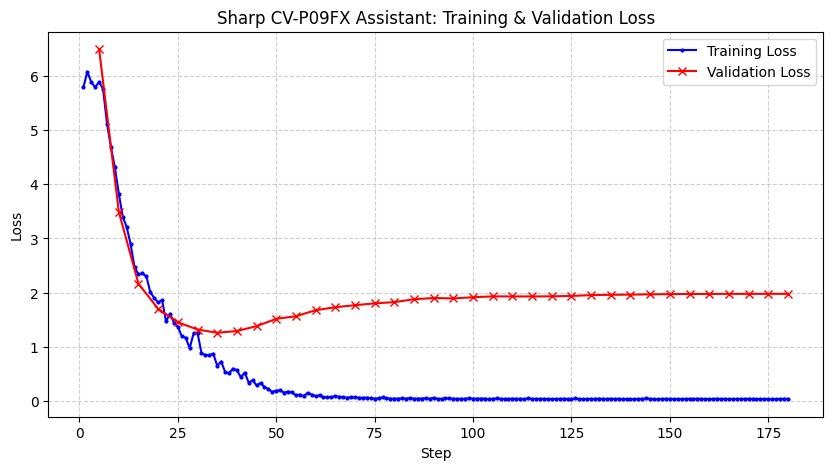

In [5]:
import matplotlib.pyplot as plt

# Extract logging history
history = trainer.state.log_history

# Filter for training loss entries
train_loss = [x['loss'] for x in history if 'loss' in x]
train_steps = [x['step'] for x in history if 'loss' in x]

# Filter for evaluation loss entries
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
eval_steps = [x['step'] for x in history if 'eval_loss' in x]

# Plotting the training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, label='Training Loss', color='blue', marker='o', markersize=2)
if eval_loss:
    plt.plot(eval_steps, eval_loss, label='Validation Loss', color='red', marker='x')

plt.title('Sharp CV-P09FX Assistant: Training & Validation Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [7]:
print(f"Initial Training Loss: {train_loss[0]:.4f}")
if eval_loss:
    print(f"Initial Validation Loss: {eval_loss[0]:.4f}")
print(f"Max Training Loss: {max(train_loss):.4f}")

Initial Training Loss: 5.7923
Initial Validation Loss: 6.4981
Max Training Loss: 6.0805


### 🔍 Analysis: Validation Plateau & Overfitting

You noticed that the **Validation Loss** stopped decreasing around step 35, even though the **Training Loss** continued to fall. This is a classic sign of the model starting to 'memorize' the specific training examples (overfitting) rather than learning general patterns.

*   **Optimal Point**: In this run, step 35-40 was likely the 'sweet spot' where the model was most accurate on unseen data.
*   **Why 180 steps then?**: Small models (350M) sometimes benefit from 'over-training' to ensure they strictly follow technical facts (like the 125V requirement), even if the general validation loss plateaus.
*   **Improvement**: In the future, we could implement **Early Stopping** to automatically stop training once the validation loss stops improving for a certain number of steps.

### 🧩 How LoRA Merges with the Base Model

To understand how the output is "added," imagine a single layer in the model. Normally, it takes an input ($x$) and multiplies it by a weight matrix ($W$) to get an output ($y$):

$$y = W \times x$$

#### 1. The "Frozen" Part ($W$)
In our fine-tuning, $W$ represents the original 350M parameters of the **LiquidAI** model. We **freeze** these. They do not change. They still contain general knowledge about language.

#### 2. The "Adapter" Part ($\Delta W$)
Instead of changing $W$, we add a separate path called an **adapter**. This adapter consists of two much smaller matrices, **A** and **B**. The "Rank" (which we set to 64) is the size of these matrices.

#### 3. The Inference Math
When you ask the model a question ($x$), the input goes through **both** paths at the same time:

1.  **Path A (Original):** Input $\times$ Frozen Weights
2.  **Path B (LoRA):** Input $\times$ Adapter A $\times$ Adapter B

Finally, the results are summed together:

$$\text{Final Output} = (W \times x) + (B \times A \times x)$$

#### Why is this better?
*   **Memory:** We only save the small A and B matrices (the LoRA weights), not a whole new 350M parameter model.
*   **No Forgetting:** Because the original $W$ is untouched, the model retains its basic ability to speak, while the $(B \times A)$ part adds the specific knowledge about the **Sharp AC manual**.

In [ ]:
import json

def find_entry_with_question(filepath, question_keyword):
    with open(filepath, 'r') as f:
        for line in f:
            entry = json.loads(line)
            if question_keyword.lower() in entry['text'].lower():
                return entry
    return None

# Assuming DATASET_PATH is defined in a previous cell
question_to_check = "What power supply does the Sharp CV-P09FX require?"
found_entry = find_entry_with_question(DATASET_PATH, question_to_check)

if found_entry:
    print(f"Found entry in {DATASET_PATH} for '{question_to_check}':\n")
    print(found_entry['text'])
else:
    print(f"No entry found containing '{question_to_check}' in {DATASET_PATH}")

In [6]:
# ============================================================
# Inference — Test your fine-tuned LFM2.5-350M AC assistant
# Run AFTER train.py has completed
# ============================================================

import torch
from unsloth import FastLanguageModel

# ──────────────────────────────────────────────
# CONFIG — must match train.py settings
# ──────────────────────────────────────────────
LORA_SAVE_DIR  = "./lfm25_350m_ac_lora"
BASE_MODEL     = "LiquidAI/LFM2.5-350M"
MAX_SEQ_LENGTH = 512
LOAD_IN_4BIT   = True

SYSTEM_PROMPT = (
    "You are a helpful assistant for the Sharp CV-P09FX portable air conditioner. "
    "Answer questions accurately based on the product manual."
)

# Inference settings (recommended by Liquid AI)
GEN_CONFIG = dict(
    temperature      = 0.1,
    top_k            = 50,
    top_p            = 0.1,
    repetition_penalty = 1.05,
    max_new_tokens   = 256,
)

# ──────────────────────────────────────────────
# LOAD MODEL
# ──────────────────────────────────────────────
print(f"Loading base model + LoRA adapters from {LORA_SAVE_DIR}...")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = LORA_SAVE_DIR,   # Load LoRA adapter (contains base model ref)
    max_seq_length = MAX_SEQ_LENGTH,
    load_in_4bit   = LOAD_IN_4BIT,
)

FastLanguageModel.for_inference(model)  # Enable optimized inference mode

# Explicitly set pad_token_id for generation
if tokenizer.pad_token_id is None:
    if tokenizer.eos_token_id is not None:
        model.config.pad_token_id = tokenizer.eos_token_id
    else:
        # Fallback if neither pad_token_id nor eos_token_id is found
        model.config.pad_token_id = 0 # Or another appropriate default
else:
    model.config.pad_token_id = tokenizer.pad_token_id

print("Model ready.\n")


def ask(question: str) -> str:
    """Format a question in ChatML and run inference."""
    messages = [
        {"role": "system",    "content": SYSTEM_PROMPT},
        {"role": "user",      "content": question},
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt = True,
        tokenize              = False,
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    print(tokenizer.decode(inputs["input_ids"][0]))
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            **GEN_CONFIG,
            pad_token_id = model.config.pad_token_id, # Use the explicitly set pad_token_id
        )

    # Decode only the newly generated tokens
    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


# ──────────────────────────────────────────────
# TEST QUESTIONS
# ──────────────────────────────────────────────
test_questions = [
   #"What window widths are supported for installing the window panel?"
   # "How do I drain the water when the lamps are blinking?",
   # "What fan speeds are available in Cool mode?",
   # "How often should I clean the air filter?",
   # "Why do I need to wait 3 minutes before restarting the unit?",
    "What power supply does the Sharp CV-P09FX require?",
]

print("=" * 60)
print("  Fine-tuned LFM2.5-350M — AC Manual Assistant")
print("=" * 60)

for q in test_questions:
    print(f"\nQ: {q}")
    answer = ask(q)
    print(f"A: {answer}")
    print("-" * 60)

# ──────────────────────────────────────────────
# INTERACTIVE MODE
# ──────────────────────────────────────────────
print("\n\nEntering interactive mode. Type 'quit' to exit.\n")
while True:
    user_input = input("Your question: ").strip()
    if user_input.lower() in ("quit", "exit", "q"):
        print("Goodbye!")
        break
    if not user_input:
        continue
    print(f"\nAnswer: {ask(user_input)}\n")

Loading base model + LoRA adapters from ./lfm25_350m_ac_lora...
==((====))==  Unsloth 2026.4.6: Fast Lfm2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Both `max_new_tokens` (=256) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Model ready.

  Fine-tuned LFM2.5-350M — AC Manual Assistant

Q: What power supply does the Sharp CV-P09FX require?
<|startoftext|><|startoftext|><|im_start|>system
You are a helpful assistant for the Sharp CV-P09FX portable air conditioner. Answer questions accurately based on the product manual.<|im_end|>
<|im_start|>user
What power supply does the Sharp CV-P09FX require?<|im_end|>
<|im_start|>assistant

A: The unit requires a three-pin grounded electrical AC socket rated 125V, 60Hz, and 15 amps or more. Do not use extension cords. The power plug has a built-in fuse and must always be checked before use using the RESET and TEST buttons on the plug.
------------------------------------------------------------


Entering interactive mode. Type 'quit' to exit.



KeyboardInterrupt: Interrupted by user

## 🎓 Lessons Learned & Demo Summary

During the fine-tuning of the **Sharp CV-P09FX Assistant**, we discovered several critical factors for successfully specializing a small (350M) model:

### 1. The Capacity Challenge (LoRA Rank)
*   **Finding**: Standard LoRA ranks (e.g., 8 or 16) were insufficient for the model to accurately recall specific technical details like voltage or fan modes.
*   **Solution**: Increasing `LORA_RANK` to **64** provided the 'memory capacity' needed to store exact manual specifications without forgetting them.

### 2. Overcoming Pre-trained Bias (Epochs)
*   **Finding**: At 3 epochs, the model still defaulted to general knowledge (e.g., assuming a 12V power supply common in electronics).
*   **Solution**: Extending training to **30 epochs** allowed the model to successfully 'overwrite' its general weights with the specific **125V** requirements from the Sharp manual.

### 3. Prompt Alignment
*   **Finding**: If the `SYSTEM_PROMPT` used during inference differs even slightly from the one used in training, the model may hallucinate or fail to use its fine-tuned knowledge.
*   **Solution**: Maintain a strict 1:1 match between the training and inference system prompts.

### 4. Efficiency with Unsloth
*   **Finding**: Fine-tuning even for 30 epochs on a T4 GPU was remarkably fast thanks to Unsloth's optimizations and 4-bit quantization, making this workflow highly accessible for edge-case or domain-specific technical assistants.